In [1]:
import pandas as pd 
df=pd.read_csv(r"D:\__Projects\Graduation---Project\DL\Diabetic Retinopathy\Data\concat_data.csv")
print(df["diagnosis"].value_counts())


diagnosis
1    1857
0    1805
Name: count, dtype: int64


In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm
from torchvision.datasets import ImageFolder

# 1. إعدادات الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_root = r"D:\__Projects\Graduation---Project\DL\Diabetic Retinopathy\Data\colored_images"

# 2. التحويلات (Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. الـ Dataset Wrapper (🔥 تم تصحيحه هنا بالاعتماد على اسم الفولدر الفعلي)
class RetinaDatasetWrapper(Dataset):
    def __init__(self, full_dataset, indices, transform=None):
        self.full_dataset = full_dataset
        self.indices = indices
        self.transform = transform
        
    def __len__(self):
        return len(self.indices)
        
    def __getitem__(self, idx):
        img_path, _ = self.full_dataset.samples[self.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        # 🔥 فحص اسم الفولدر في المسار مباشرة لضمان الدقة
        # إذا كان اسم الفولدر يحتوي على No_DR أو no_dr يأخذ 0، غير ذلك (مصاب) يأخذ 1
        if "no_dr" in img_path.lower():
            binary_label = 0
        else:
            binary_label = 1
            
        return img, torch.tensor(binary_label, dtype=torch.long)

# 4. تحميل البيانات الأصلية وتصحيح توزيع الليبلز
base_dataset = ImageFolder(data_root)

# 🔥 تم تصحيح بناء المصفوفة بناء على اسم الفولدر الفعلي لكل صورة
binary_labels = []
for img_path, _ in base_dataset.samples:
    if "no_dr" in img_path.lower():
        binary_labels.append(0)
    else:
        binary_labels.append(1)

# طباعة التوزيع الحقيقي للتأكيد تماماً
print(f"--- Dataset Verification (Fixed) ---")
print(f"Total Images   : {len(binary_labels)}")
print(f"No_DR (Class 0): {binary_labels.count(0)}") # هنا سيطبع الـ 1805
print(f"DR    (Class 1): {binary_labels.count(1)}") # هنا سيطبع الـ 1857
print(f"------------------------------------")

# تقسيم البيانات (Train / Val / Test)
train_val_idx, test_idx, train_val_lbls, test_lbls = train_test_split(
    np.arange(len(binary_labels)), binary_labels, test_size=0.15, stratify=binary_labels, random_state=42
)

train_idx, val_idx, train_lbls, val_lbls = train_test_split(
    train_val_idx, train_val_lbls, test_size=0.15, stratify=train_val_lbls, random_state=42
)

print(f" Data Splits: Train={len(train_idx)} | Val={len(val_idx)} | Test={len(test_idx)}")

# 5. الـ Data Loaders
train_loader = DataLoader(RetinaDatasetWrapper(base_dataset, train_idx, train_transform), batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(RetinaDatasetWrapper(base_dataset, val_idx, val_test_transform), batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(RetinaDatasetWrapper(base_dataset, test_idx, val_test_transform), batch_size=32, shuffle=False, pin_memory=True)

# 6. حساب أوزان الكلاسات الجديدة
class_counts = np.bincount(train_lbls)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
weight_tensor = torch.FloatTensor(class_weights).to(device)

# 7. بناء الموديل
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 2) 
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# 8. تدريب الموديل
epochs = 10  
best_val_acc = 0.0
save_path = r'D:\__Projects\Graduation---Project\app\models\resnet18_diabetic_retinopathy_binary.pth'

os.makedirs(os.path.dirname(save_path), exist_ok=True)

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        train_correct += (preds == labels).sum().item()
        
    train_loss = train_loss / len(train_idx)
    train_acc = train_correct / len(train_idx)
    
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()
            
    val_loss = val_loss / len(val_idx)
    val_acc = val_correct / len(val_idx)
    
    print(f" Epoch {epoch+1} -> Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f" Saved New Best Weights with Val Acc: {val_acc:.4f}")

print("\n Training complete. Best Binary Model Saved Successfully.")

# 9. التقييم النهائي على الـ Test Set
print("\n Evaluating Best Model on the Untouched Test Set...")
model.load_state_dict(torch.load(save_path))
model.eval()

all_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.numpy())

print("\n Final Classification Report (Binary - Retina Test Set):")
# 🔥 الترتيب الآن أصبح صحيح ومطابق 100% للواقع الفعلي للداتا
target_names = ['No_DR', 'DR']
print(classification_report(all_test_labels, all_preds, target_names=target_names))

--- Dataset Verification (Fixed) ---
Total Images   : 3662
No_DR (Class 0): 1805
DR    (Class 1): 1857
------------------------------------
 Data Splits: Train=2645 | Val=467 | Test=550


Epoch 1/10: 100%|██████████| 83/83 [00:18<00:00,  4.46it/s]


 Epoch 1 -> Train Loss: 0.1818 Acc: 0.9342 | Val Loss: 0.1167 Acc: 0.9615
 Saved New Best Weights with Val Acc: 0.9615


Epoch 2/10: 100%|██████████| 83/83 [00:22<00:00,  3.68it/s]


 Epoch 2 -> Train Loss: 0.1070 Acc: 0.9686 | Val Loss: 0.1104 Acc: 0.9593


...

 Epoch 8 -> Train Loss: 0.0553 Acc: 0.9807 | Val Loss: 0.1114 Acc: 0.9743
 Saved New Best Weights with Val Acc: 0.9743


Epoch 9/10: 100%|██████████| 83/83 [00:18<00:00,  4.52it/s]


 Epoch 9 -> Train Loss: 0.0473 Acc: 0.9860 | Val Loss: 0.1138 Acc: 0.9743


Epoch 10/10: 100%|██████████| 83/83 [00:18<00:00,  4.55it/s]


 Epoch 10 -> Train Loss: 0.0407 Acc: 0.9875 | Val Loss: 0.1059 Acc: 0.9700

 Training complete. Best Binary Model Saved Successfully.

 Evaluating Best Model on the Untouched Test Set...

 Final Classification Report (Binary - Retina Test Set):
              precision    recall  f1-score   support

       No_DR       0.99      0.97      0.98       271
          DR       0.97      0.99      0.98       279

    accuracy                           0.98       550
   macro avg       0.98      0.98      0.98       550
weighted avg       0.98      0.98      0.98       550



Prediction: DR (99.98%)
Saved Grad-CAM result to: D:\__Projects\Graduation---Project\gradcam_result.png


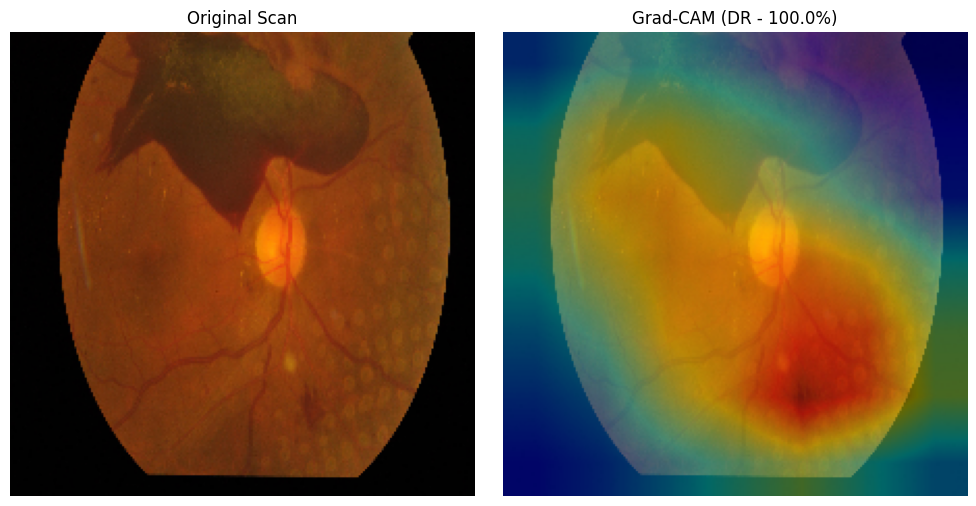

In [ ]:
import os
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. إعدادات الجهاز والموديل
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = r'D:\__Projects\Graduation---Project\app\models\resnet18_diabetic_retinopathy_binary.pth'

# 2. بناء الموديل وتحميل الأوزان المدربة
model = models.resnet18()
in_features = model.fc.in_features
model.fc = torch.nn.Sequential(
    torch.nn.BatchNorm1d(in_features),
    torch.nn.Dropout(p=0.4),
    torch.nn.Linear(in_features, 2)
)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# 3. دالة التقاط الـ Gradients والـ Activations من آخر طبقة (layer4)
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# ربط الـ Hooks بآخر طبقة كونفلوشن في ريزنت 18
target_layer = model.layer4
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# 4. تجهيز الصور (Preprocessing)
def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    raw_image = Image.open(img_path).convert('RGB')
    input_tensor = transform(raw_image).unsqueeze(0).to(device)
    return raw_image, input_tensor

# 5. دالة توليد الـ Grad-CAM
def generate_gradcam(img_path, save_output_path=None):
    global gradients, activations
    
    # تحميل وتجهيز الصورة
    raw_img, input_tensor = preprocess_image(img_path)
    
    # Forward Pass
    output = model(input_tensor)
    _, preds = output.max(1)
    predicted_class = preds.item()
    
    # حساب الاحتماليات (Confidence)
    probabilities = torch.softmax(output, dim=1)
    confidence = probabilities[0][predicted_class].item() * 100
    
    class_names = ['No_DR', 'DR']
    print(f"Prediction: {class_names[predicted_class]} ({confidence:.2f}%)")
    
    # Backward Pass للكلاس المتوقع
    model.zero_grad()
    output[0, predicted_class].backward()
    
    # حساب أوزان الـ Gradients (Global Average Pooling)
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    
    # ضرب الـ Activations في الأوزان
    for i in range(activations.size(1)):
        activations[:, i, :, :] *= pooled_gradients[i]
        
    # حساب الـ Heatmap (متوسط قنوات الـ activations المتأثرة)
    heatmap = torch.mean(activations, dim=1).squeeze().cpu().detach().numpy()
    
    # تطبيق ReLU (الاحتفاظ بالإشارات الإيجابية المؤثرة فقط)
    heatmap = np.maximum(heatmap, 0)
    
    # عمل Normalization للـ Heatmap بين 0 و 1
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)
        
    # تكبير الـ Heatmap لحجم الصورة الأصلية
    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (224, 224))
    
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    # تحويل الـ Heatmap لصورة ملونة (Jet Colormap)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    # دمج الـ Heatmap مع الصورة الأصلية بنسبة 60% للصورة و 40% للحرارة
    superimposed_img = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)
    
    # عرض النتيجة النهائية بالـ Matplotlib
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Scan")
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM ({class_names[predicted_class]} - {confidence:.1f}%)")
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    
    if save_output_path:
        plt.savefig(save_output_path, bbox_inches='tight')
        print(f"Saved Grad-CAM result to: {save_output_path}")
        
    plt.show()
test_image_path = r"D:\__Projects\Graduation---Project\DL\Diabetic Retinopathy\Data\colored_images\DR\0e0fc1d9810c.png" 
output_result_path = r"D:\__Projects\Graduation---Project\gradcam_result.png"

